## S) Notebook for Supplementary Material: Sensitivity Analysis

##### Before running this notebook, you need to run the following snakemake commands to produce the necessary outputs
1) snakemake -c1 flood_model_sensitivity_run (runs all permutations of the ADM0 CI analysis for sensitivity run)
2) TODO: Adaptation sensitivity

##### 1) Import Libraries

In [1]:
import os
import yaml
import pandas as pd
import numpy as np
import geopandas as gpd
from scipy import stats
from statsmodels.stats.anova import anova_lm
from statsmodels.formula.api import ols
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Rectangle
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

##### 2) Define Functions

In [2]:
def combine_national_ci(country_list):
    """
    Combine national CI values across all model / metric / vulnerability / social combinations.

    Returns a pandas DataFrame with columns:
        Country, CI, Model, Vulnerability, Protected, Social
    """

    MODELS = ['jrc', 'wri', 'giri']
    METRICS = ['protected_AAR', 'AAR']
    VULN_CURVES = ['JRC', 'EXP', 'BER']
    SOCIALS = ['gdp', 'rwi']

    rows = []

    for country in country_list:
        for model in MODELS:
            for metric in METRICS:
                for vuln in VULN_CURVES:
                    for social in SOCIALS:

                        path = os.path.join(
                            "..", "data", "results", "social_flood", "countries", country,
                            "inequality_metrics",
                            f"{country}_ADM0_metrics_{model}-flood_{metric}_V-{vuln}_S-{social}.gpkg"
                        )

                        if not os.path.exists(path):
                            continue

                        try:
                            gdf = gpd.read_file(path)

                            ci = float(gdf.iloc[0]["CI"])

                            rows.append({
                                "Country": country,
                                "CI": ci,
                                "Model": model.upper(),
                                "Vulnerability": vuln,
                                "Protected": "Yes" if metric == "protected_AAR" else "No",
                                "Social": social
                            })

                        except Exception as e:
                            print(f"Error reading {path}: {e}")

    return pd.DataFrame(rows)

def run_all_countries(data, response_var='CI'):
    countries = data['Country'].unique()
    results_summary = []

    for country in countries:
        country_data = data[data['Country'] == country].copy()

        if len(country_data) < 6: # Need minimum observations
            continue

        try:
            # Simplified model - main effects only
            # formula = f'{response_var} ~ C(Model) + C(Vulnerability) + C(Protected)'
            formula = (f'{response_var} ~ C(Model) + C(Vulnerability) + C(Protected) + C(Social) + '
           'C(Model):C(Vulnerability) + C(Model):C(Protected) + C(Model):C(Social) + '
           'C(Vulnerability):C(Protected) + C(Vulnerability):C(Social) + '
           'C(Protected):C(Social)')
            model = ols(formula, data=country_data).fit()
            anova_table = anova_lm(model, typ=2)

            # Calculate effect sizes
            ss_total = anova_table['sum_sq'].sum()
            anova_table['eta_squared'] = anova_table['sum_sq'] / ss_total

            # Extract key statistics
            result = {
                'Country': country,
                "R_squared": model.rsquared,
                "Model_F": anova_table.loc['C(Model)', 'F'] if 'C(Model)' in anova_table.index else np.nan,
                'Model_p': anova_table.loc['C(Model)', 'PR(>F)'] if 'C(Model)' in anova_table.index else np.nan,
                'Model_eta_sq': anova_table.loc['C(Model)', 'eta_squared'] if 'C(Model)' in anova_table.index else np.nan,
                'Vulnerability_F': anova_table.loc['C(Vulnerability)', 'F'] if 'C(Vulnerability)' in anova_table.index else np.nan,
                'Vulnerability_p': anova_table.loc['C(Vulnerability)', 'PR(>F)'] if 'C(Vulnerability)' in anova_table.index else np.nan,
                'Vulnerability_eta_sq': anova_table.loc['C(Vulnerability)', 'eta_squared'] if 'C(Vulnerability)' in anova_table.index else np.nan,
                'Protected_F': anova_table.loc['C(Protected)', 'F'] if 'C(Protected)' in anova_table.index else np.nan,
                'Protected_p': anova_table.loc['C(Protected)', 'PR(>F)'] if 'C(Protected)' in anova_table.index else np.nan,
                'Protected_eta_sq': anova_table.loc['C(Protected)', 'eta_squared'] if 'C(Protected)' in anova_table.index else np.nan,
                'Social_F': anova_table.loc['C(Social)', 'F'] if 'C(Social)' in anova_table.index else np.nan,
                'Social_p': anova_table.loc['C(Social)', 'PR(>F)'] if 'C(Social)' in anova_table.index else np.nan,
                'Social_eta_sq': anova_table.loc['C(Social)', 'eta_squared'] if 'C(Social)' in anova_table.index else np.nan
            }

            results_summary.append(result)

        except Exception as e:
            print(f'Skipping {country}: {e}')
            continue

    return pd.DataFrame(results_summary)

##### 3) Load and prepare data

In [3]:
# Load countries from config file
with open(os.path.join("..", "config", "config.yaml"), "r") as file:
    config = yaml.safe_load(file)
countries = config.get("iso_codes", [])
combined_national_metrics = combine_national_ci(countries)

#### 4) Run ANOVA analysis for all countries

In [12]:
ANOVA = run_all_countries(combined_national_metrics)

##### 5) ANOVA summary statistics

In [13]:
# Summary statistics
print(f"Summary across {len(ANOVA)} countries:")
print("=" * 70)

# 1. Significance counts
print("\n1. STATISTICAL SIGNIFICANCE (p < 0.05)")
print("-" * 50)
for param in ['Model', 'Vulnerability', 'Protected', 'Social']:
    sig = (ANOVA[f'{param}_p'] < 0.05).sum()
    print(f"  {param:15}: {sig:2}/{len(ANOVA)} countries ({sig/len(ANOVA)*100:5.1f}%)")

# 2. Effect sizes - full distribution
print("\n2. EFFECT SIZES (η²)")
print("-" * 50)
print(f"  {'Parameter':<15} {'Mean':>8} {'Median':>8} {'IQR':>12} {'Max':>8}")
for param in ['Model', 'Vulnerability', 'Protected', 'Social']:
    eta = ANOVA[f'{param}_eta_sq']
    q25, q75 = eta.quantile([0.25, 0.75])
    print(f"  {param:<15} {eta.mean():>8.3f} {eta.median():>8.3f} {f'[{q25:.3f}-{q75:.3f}]':>12} {eta.max():>8.3f}")

# 3. Relative importance ranking per country
print("\n3. WHICH PARAMETER DOMINATES? (highest η² per country)")
print("-" * 50)
eta_cols = ['Model_eta_sq', 'Vulnerability_eta_sq', 'Protected_eta_sq', 'Social_eta_sq']
dominant = ANOVA[eta_cols].idxmax(axis=1).str.replace('_eta_sq', '')
for param in ['Model', 'Vulnerability', 'Protected', 'Social']:
    count = (dominant == param).sum()
    print(f"  {param:15} dominant in {count:2}/{len(ANOVA)} countries ({count/len(ANOVA)*100:5.1f}%)")

# 4. Countries where protection has large effect (top 10)
print("\n4. COUNTRIES MOST SENSITIVE TO PROTECTION (top 10 by η²)")
print("-" * 50)
top_prot = ANOVA.nlargest(10, 'Protected_eta_sq')[['Country', 'Protected_eta_sq', 'Protected_p']]
for _, row in top_prot.iterrows():
    sig = '*' if row['Protected_p'] < 0.05 else ''
    print(f"  {row['Country']}: η² = {row['Protected_eta_sq']:.3f}{sig}")

# 5. Countries where protection has LIMITED effect (bottom 10)
print("\n5. COUNTRIES LEAST SENSITIVE TO PROTECTION (top 10 by η²)")
print("-" * 50)
top_prot = ANOVA.nsmallest(10, 'Protected_eta_sq')[['Country', 'Protected_eta_sq', 'Protected_p']]
for _, row in top_prot.iterrows():
    sig = '*' if row['Protected_p'] < 0.05 else ''
    print(f"  {row['Country']}: η² = {row['Protected_eta_sq']:.3f}{sig}")

# 6. Countries where model choice has large effect (top 10)
print("\n6. COUNTRIES MOST SENSITIVE TO MODEL CHOICE (top 10 by η²)")
print("-" * 50)
bottom_model = ANOVA.nlargest(10, 'Model_eta_sq')[['Country', 'Model_eta_sq', 'Model_p']]
for _, row in bottom_model.iterrows():
    sig = '*' if row['Model_p'] < 0.05 else ''
    print(f"  {row['Country']}: η² = {row['Model_eta_sq']:.3f}{sig}")

# 7. Countries where model choice has LIMITED effect (bottom 10)
print("\n7. COUNTRIES LEAST SENSITIVE TO MODEL CHOICE (bottom 10 by η²)")
print("-" * 50)
bottom_model = ANOVA.nsmallest(10, 'Model_eta_sq')[['Country', 'Model_eta_sq', 'Model_p']]
for _, row in bottom_model.iterrows():
    sig = '*' if row['Model_p'] < 0.05 else ''
    print(f"  {row['Country']}: η² = {row['Model_eta_sq']:.3f}{sig}")

# 8. Countries where socioeconomic choice has large effect (top 10)
print("\n8. COUNTRIES MOST SENSITIVE TO SOCIOECONOMIC CHOICE (top 10 by η²)")
print("-" * 50)
bottom_model = ANOVA.nlargest(10, 'Social_eta_sq')[['Country', 'Social_eta_sq', 'Social_p']]
for _, row in bottom_model.iterrows():
    sig = '*' if row['Social_p'] < 0.05 else ''
    print(f"  {row['Country']}: η² = {row['Social_eta_sq']:.3f}{sig}")

# 9. Countries where socioeconomic choice has LIMITED effect (bottom 10)
print("\n9. COUNTRIES LEAST SENSITIVE TO SOCIOECONOMIC CHOICE (bottom 10 by η²)")
print("-" * 50)
bottom_model = ANOVA.nsmallest(10, 'Social_eta_sq')[['Country', 'Social_eta_sq', 'Social_p']]
for _, row in bottom_model.iterrows():
    sig = '*' if row['Social_p'] < 0.05 else ''
    print(f"  {row['Country']}: η² = {row['Social_eta_sq']:.3f}{sig}")

# 10. Model R² summary
print("\n10. MODEL FIT (R²)")
print("-" * 50)
print(f"  Mean:   {ANOVA['R_squared'].mean():.3f}")
print(f"  Median: {ANOVA['R_squared'].median():.3f}")
print(f"  Range:  {ANOVA['R_squared'].min():.3f} - {ANOVA['R_squared'].max():.3f}")
print(f"  Countries with R² > 0.95: {(ANOVA['R_squared'] > 0.95).sum()}/{len(ANOVA)}")

# # 7. Correlation between sensitivities
# print("\n7. ARE SENSITIVITIES CORRELATED ACROSS COUNTRIES?")
# print("-" * 50)
# print("  (Spearman correlation between η² values)")
# from scipy.stats import spearmanr
# eta_df = ANOVA[['Model_eta_sq', 'Protected_eta_sq', 'Social_eta_sq', 'Vulnerability_eta_sq']]
# params = ['Model', 'Protected', 'Social', 'Vulnerability']
# for i, p1 in enumerate(params):
#     for p2 in params[i+1:]:
#         r, p = spearmanr(eta_df[f'{p1}_eta_sq'], eta_df[f'{p2}_eta_sq'])
#         sig = '*' if p < 0.05 else ''
#         print(f"  {p1:13} vs {p2:13}: r = {r:+.3f}{sig}")

Summary across 92 countries:

1. STATISTICAL SIGNIFICANCE (p < 0.05)
--------------------------------------------------
  Model          : 92/92 countries (100.0%)
  Vulnerability  : 66/92 countries ( 71.7%)
  Protected      : 67/92 countries ( 72.8%)
  Social         : 86/92 countries ( 93.5%)

2. EFFECT SIZES (η²)
--------------------------------------------------
  Parameter           Mean   Median          IQR      Max
  Model              0.545    0.588 [0.319-0.807]    0.962
  Vulnerability      0.029    0.008 [0.003-0.033]    0.269
  Protected          0.083    0.007 [0.000-0.083]    0.893
  Social             0.163    0.060 [0.012-0.221]    0.795

3. WHICH PARAMETER DOMINATES? (highest η² per country)
--------------------------------------------------
  Model           dominant in 70/92 countries ( 76.1%)
  Vulnerability   dominant in  1/92 countries (  1.1%)
  Protected       dominant in  5/92 countries (  5.4%)
  Social          dominant in 16/92 countries ( 17.4%)

4. COUNTR

##### 6) Plot ANOVA effect size distributions

Text(0, 0.5, 'Effect Size (η²)')

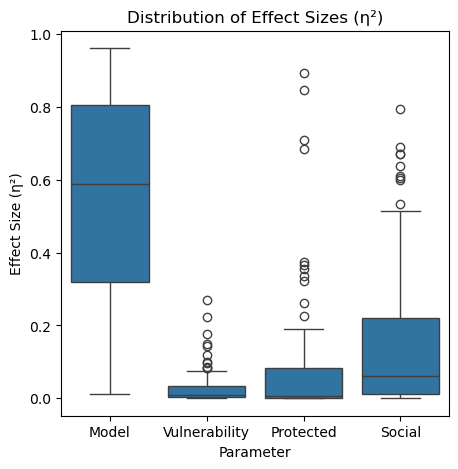

In [14]:
fig, ax = plt.subplots(figsize=(5, 5))

# Percentage of countries with significant effects
parameters = ['Model', 'Vulnerability', 'Protected', 'Social']
sig_counts = []
total_countries = len(ANOVA)

eta_data = []
for param in parameters:
    eta_values = ANOVA[f'{param}_eta_sq'].dropna()
    for val in eta_values:
        eta_data.append({'Parameter': param, 'Eta_Squared': val})

eta_df = pd.DataFrame(eta_data)
sns.boxplot(data=eta_df, x='Parameter', y='Eta_Squared', ax=ax)
ax.set_title('Distribution of Effect Sizes (η²)')
ax.set_ylabel('Effect Size (η²)')